In [157]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

In [158]:
seed = 42

root_path = "/home/stefan/ioai-prep/kits/gaia/memory-trace"

In [159]:
model_A = joblib.load(f"{root_path}/model_A.joblib")
model_B = joblib.load(f"{root_path}/model_B.joblib")

In [160]:
model_A

Pipeline(steps=[('scaler', StandardScaler()),
                ('clf',
                 MLPClassifier(alpha=1e-06, batch_size=256,
                               hidden_layer_sizes=(256, 256, 256),
                               random_state=1, verbose=True))])

# Data

In [161]:
df = pd.read_csv(f"{root_path}/train_data.csv")
df.head()

,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,...,feature_45,feature_46,feature_47,feature_48,feature_49,feature_50,feature_51,feature_52,y,row_id
0,20000,2,2,1,24,2,2,-1,-1,-2,...,482,433,123,681,801,512,436,179,1,0
1,120000,2,2,2,26,-1,2,0,0,0,...,574,429,652,645,456,826,427,856,1,1
2,90000,2,2,2,34,0,0,0,0,0,...,571,806,795,995,922,940,25,869,0,2
3,50000,2,2,1,37,0,0,0,0,0,...,618,570,476,120,6,47,450,781,0,3
4,50000,1,2,1,57,-1,0,-1,0,0,...,22,0,591,783,788,590,557,413,0,4


In [162]:
features = df.drop(["row_id", "y"], axis=1)
y = df["y"]

In [163]:
preds_a = model_A.predict_proba(features.values)[:, 1]
conf_a = np.abs(y - preds_a)  # 0 means it was fully confident

len(conf_a)

30000

In [212]:
thresh = 0.003
(conf_a > thresh).sum()

np.int64(6124)

<Axes: ylabel='y'>

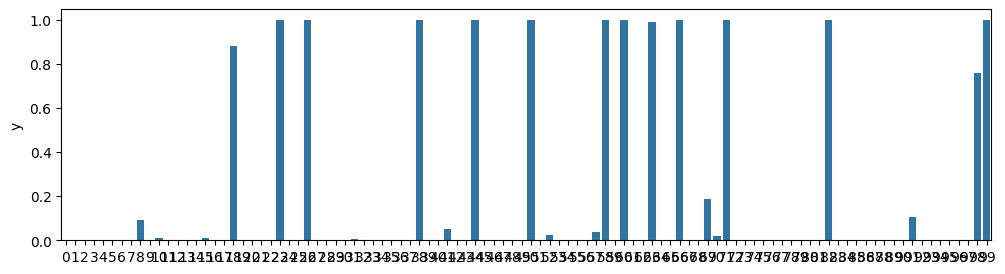

In [213]:
plt.figure(figsize=(12,3))
sns.barplot(data=conf_a[:100])

In [215]:
submission = pd.DataFrame({
    "subtaskID": 1,
    "datapointID": df["row_id"],
    "answer": (common).astype(int)
})

submission.head()

,subtaskID,datapointID,answer
0,1,0,0
1,1,1,0
2,1,2,0
3,1,3,0
4,1,4,0


In [216]:
submission.to_csv(f"{root_path}/submission.csv", index=False)